# Task 5 – Background Noise

For a subset of **100 samples** mix real-world background sounds at target SNR
and compare system performance with Task 1.

SNR levels tested: **20 dB**, **10 dB**, **0 dB** (equal speech/noise power).

**Noise source (in priority order):**
1. WAV files in `data/background_noise/` — place UrbanSound8K clips here manually
2. HuggingFace streaming of `danavery/urbansound8k`
3. **Babble noise** — speech from other enrolled speakers mixed as noise (automatic fallback)

**Mix formula:**
```
P_noise_target = P_speech / 10^(SNR_dB / 10)
noise_scaled   = noise * sqrt(P_noise_target / P_noise)
mixed          = speech + noise_scaled
```

**Prerequisites:** `task1_baseline.ipynb` must have been run.

## 0. Setup

In [1]:
import sys, json, random
from pathlib import Path

SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt

from config import cfg
from embeddings import load_model, load_audio
from database import get_collection, list_enrolled
from threshold import compute_eer, compute_metrics_at_threshold, _load_enrolled_embeddings_bulk

RESULTS_DIR = cfg.paths.results_dir
TEST_DIR    = cfg.paths.test_dir
RANDOM_SEED = cfg.dataset.random_seed
SAMPLE_RATE = cfg.audio.sample_rate  # 16000

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_DIR}")

Results → D:\pwr\biometria\lab\voice\results


## 1. Load Task 1 baseline

In [2]:
task1_path = RESULTS_DIR / "task1_results.json"
if not task1_path.exists():
    raise FileNotFoundError("Run task1_baseline.ipynb first to generate task1_results.json")

with open(task1_path) as f:
    task1 = json.load(f)

eer_threshold = task1["eer_threshold"]
print(f"Task 1 baseline:")
print(f"  EER       = {task1['eer_pct']:.2f}%")
print(f"  Accuracy  = {task1['accuracy_at_eer_pct']:.2f}%")
print(f"  Threshold = {eer_threshold:.4f}")

Task 1 baseline:
  EER       = 0.11%
  Accuracy  = 99.89%
  Threshold = 0.3969


## 2. Load / download background noise

Tries three sources in order:
1. `data/background_noise/*.wav` (pre-placed UrbanSound8K clips)
2. HuggingFace streaming of `danavery/urbansound8k`
3. Babble noise fallback — speech from other enrolled speakers

In [3]:
BG_NOISE_DIR  = cfg.paths.data_dir / "background_noise"
N_NOISE_CLIPS = 30   # target number of distinct noise clips

BG_NOISE_DIR.mkdir(parents=True, exist_ok=True)
noise_files = sorted(BG_NOISE_DIR.glob("*.wav"))

if len(noise_files) >= N_NOISE_CLIPS:
    print(f"[source: local] {len(noise_files)} noise clips in {BG_NOISE_DIR}")
else:
    # --- Try HuggingFace streaming ---
    try:
        print("Trying HuggingFace: danavery/urbansound8k ...")
        from datasets import load_dataset
        ds = load_dataset(
            "danavery/urbansound8k",
            split="train",
            streaming=True,
            trust_remote_code=True,
        )
        count = len(noise_files)
        for sample in ds:
            arr = np.array(sample["audio"]["array"], dtype=np.float32)
            sr  = sample["audio"]["sampling_rate"]
            w   = torch.tensor(arr).unsqueeze(0)
            if sr != SAMPLE_RATE:
                w = torchaudio.functional.resample(w, sr, SAMPLE_RATE)
            out_path = BG_NOISE_DIR / f"urban_{count:04d}.wav"
            torchaudio.save(str(out_path), w, SAMPLE_RATE)
            count += 1
            if count >= N_NOISE_CLIPS:
                break
        noise_files = sorted(BG_NOISE_DIR.glob("*.wav"))
        print(f"[source: HuggingFace] downloaded {len(noise_files)} clips.")
    except Exception as e:
        print(f"HuggingFace download failed: {e}")
        noise_files = []

USE_BABBLE = len(noise_files) < N_NOISE_CLIPS
if USE_BABBLE:
    print("[source: babble] Will use speech from other enrolled speakers as background noise.")
else:
    print(f"Using {len(noise_files)} environmental noise clips.")

Trying HuggingFace: danavery/urbansound8k ...


d:\pwr\biometria\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFace download failed: Lazy import of LazyModule(package=None, target=speechbrain.integrations.k2_fsa, loaded=False) failed
[source: babble] Will use speech from other enrolled speakers as background noise.


C:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\inspect.py:1007: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if ismodule(module) and hasattr(module, '__file__'):


## 3. Load model and enrolled embeddings

In [4]:
print("Loading ECAPA-TDNN model...")
model = load_model()

collection   = get_collection()
enrolled_ids = set(list_enrolled(collection))
print(f"Enrolled speakers: {len(enrolled_ids)}")

enrolled_cache: dict[str, np.ndarray] = _load_enrolled_embeddings_bulk(collection)
print(f"Loaded {len(enrolled_cache)} enrolled embeddings.")

if not enrolled_ids:
    raise RuntimeError("No speakers enrolled. Run src/enroll.py first.")

d:\pwr\biometria\venv\Lib\site-packages\speechbrain\utils\parameter_transfer.py:234: UserWarning: Requested Pretrainer collection using symlinks on Windows. This might not work; see `LocalStrategy` documentation. Consider unsetting `collect_in` in Pretrainer to avoid symlinking altogether.
  warnings.warn(


Loading ECAPA-TDNN model...


Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Enrolled speakers: 140
Loaded 140 enrolled embeddings.


## 4. Select 100 test samples

In [5]:
N_GENUINE  = 50
N_IMPOSTOR = 50

rng = random.Random(RANDOM_SEED)

speaker_files: dict[str, list[Path]] = {}
for spk_dir in sorted(TEST_DIR.iterdir()):
    if spk_dir.is_dir() and spk_dir.name in enrolled_ids:
        wavs = sorted(spk_dir.rglob("*.wav"))
        if wavs:
            speaker_files[spk_dir.name] = wavs

speaker_ids = sorted(speaker_files.keys())
print(f"Speakers with test files: {len(speaker_ids)}")

genuine_pool = []
for spk_id in speaker_ids:
    for wav in speaker_files[spk_id]:
        genuine_pool.append((wav, spk_id, True))
rng.shuffle(genuine_pool)

impostor_pool = []
for spk_id in speaker_ids:
    other_ids = [s for s in speaker_ids if s != spk_id]
    if not other_ids:
        continue
    for imp_id in rng.sample(other_ids, min(2, len(other_ids))):
        impostor_pool.append((rng.choice(speaker_files[imp_id]), spk_id, False))
rng.shuffle(impostor_pool)

trials = genuine_pool[:N_GENUINE] + impostor_pool[:N_IMPOSTOR]
rng.shuffle(trials)

print(f"Genuine trials:  {sum(1 for t in trials if t[2])}")
print(f"Impostor trials: {sum(1 for t in trials if not t[2])}")
print(f"Total:           {len(trials)}")

Speakers with test files: 140
Genuine trials:  50
Impostor trials: 50
Total:           100


## 5. Noise mixing functions

In [6]:
CONDITIONS = [
    ("no_noise", "No noise",  None),
    ("snr_20db", "SNR 20 dB", 20.0),
    ("snr_10db", "SNR 10 dB", 10.0),
    ("snr_0db",  "SNR 0 dB",   0.0),
]


def fit_noise_to_speech(noise: torch.Tensor, n_samples: int) -> torch.Tensor:
    """Loop or crop noise to match speech length."""
    if noise.shape[1] < n_samples:
        repeats = (n_samples // noise.shape[1]) + 1
        noise = noise.repeat(1, repeats)
    return noise[:, :n_samples]


def mix_at_snr(
    speech: torch.Tensor,
    noise: torch.Tensor,
    snr_db: float,
) -> torch.Tensor:
    """Mix speech + noise at target SNR (dB). Noise is looped/cropped as needed."""
    noise = fit_noise_to_speech(noise, speech.shape[1])
    p_speech = speech.pow(2).mean()
    p_noise  = noise.pow(2).mean()
    if p_speech < 1e-10 or p_noise < 1e-10:
        return speech
    target_p_noise = p_speech / (10 ** (snr_db / 10))
    return speech + noise * (target_p_noise / p_noise).sqrt()


def get_noise_waveform(
    enrolled_id: str,
    noise_files: list[Path],
    speaker_files: dict[str, list[Path]],
    rng: random.Random,
    audio_cache: dict[Path, torch.Tensor],
) -> torch.Tensor | None:
    """Return a noise waveform from environmental clips or babble fallback."""
    if noise_files:
        path = rng.choice(noise_files)
        if path not in audio_cache:
            audio_cache[path] = load_audio(path)
        return audio_cache[path]

    # Babble: use speech from a DIFFERENT speaker
    other_ids = [s for s in speaker_files if s != enrolled_id]
    if not other_ids:
        return None
    babble_spk  = rng.choice(other_ids)
    babble_path = rng.choice(speaker_files[babble_spk])
    if babble_path not in audio_cache:
        audio_cache[babble_path] = load_audio(babble_path)
    return audio_cache[babble_path]


def embed_waveform(model, waveform: torch.Tensor) -> np.ndarray:
    with torch.no_grad():
        emb = model.encode_batch(waveform)
    emb = emb.squeeze().cpu().numpy().astype(np.float32)
    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


noise_source_label = "babble" if USE_BABBLE else f"{len(noise_files)} env. clips"
print(f"Conditions: {[c[1] for c in CONDITIONS]}")
print(f"Noise source: {noise_source_label}")

Conditions: ['No noise', 'SNR 20 dB', 'SNR 10 dB', 'SNR 0 dB']
Noise source: babble


## 6. Compute scores for all SNR levels

In [7]:
results: dict[str, dict] = {
    key: {"genuine": [], "impostor": []}
    for key, *_ in CONDITIONS
}

rng_mix    = random.Random(RANDOM_SEED + 1)
audio_cache: dict[Path, torch.Tensor] = {}

def get_cached(path: Path) -> torch.Tensor:
    if path not in audio_cache:
        audio_cache[path] = load_audio(path)
    return audio_cache[path]


print(f"Processing {len(trials)} trials × {len(CONDITIONS)} conditions...")

for i, (wav_path, enrolled_id, is_genuine) in enumerate(trials):
    if enrolled_id not in enrolled_cache:
        print(f"  [warn] {enrolled_id}: no enrolled embedding, skipping")
        continue

    enrolled_emb = enrolled_cache[enrolled_id]
    speech = get_cached(wav_path)

    # Pre-pick one noise clip per trial (same noise across all SNR levels)
    noise_wav = get_noise_waveform(
        enrolled_id, list(noise_files), speaker_files, rng_mix, audio_cache
    )

    for key, label, snr_db in CONDITIONS:
        if snr_db is None or noise_wav is None:
            w = speech
        else:
            w = mix_at_snr(speech, noise_wav, snr_db)

        query_emb = embed_waveform(model, w)
        score = float(np.dot(query_emb, enrolled_emb))

        bucket = "genuine" if is_genuine else "impostor"
        results[key][bucket].append(score)

    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(trials)}...")

print("Done.")

Processing 100 trials × 4 conditions...
  25/100...
  50/100...
  75/100...
  100/100...
Done.


## 7. Metrics per SNR level

In [8]:
rows = []
print(f"{'Condition':<12} {'N gen':>6} {'N imp':>6} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("-" * 58)

for key, label, snr_db in CONDITIONS:
    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])
    if len(gen) < 2 or len(imp) < 2:
        print(f"  {label}: not enough samples")
        continue

    eer, _ = compute_eer(gen, imp)
    m = compute_metrics_at_threshold(gen, imp, eer_threshold)
    row = {
        "key":          key,
        "label":        label,
        "snr_db":       snr_db,
        "n_genuine":    len(gen),
        "n_impostor":   len(imp),
        "eer_pct":      round(eer * 100, 2),
        "far_pct":      round(m["far"] * 100, 2),
        "frr_pct":      round(m["frr"] * 100, 2),
        "accuracy_pct": round(m["accuracy"] * 100, 2),
    }
    rows.append(row)
    print(
        f"  {label:<10} {len(gen):>6} {len(imp):>6}"
        f" {eer*100:>8.2f} {m['far']*100:>8.2f}"
        f" {m['frr']*100:>8.2f} {m['accuracy']*100:>8.2f}"
    )

print("-" * 58)
print(f"  [Task 1 baseline: EER={task1['eer_pct']:.2f}%  Acc={task1['accuracy_at_eer_pct']:.2f}%]")
print(f"  [Noise source: {noise_source_label}]")

Condition     N gen  N imp     EER%     FAR%     FRR%     Acc%
----------------------------------------------------------
  No noise       50     50     1.00     0.00     0.00   100.00
  SNR 20 dB      50     50     1.00     0.00     0.00   100.00
  SNR 10 dB      50     50     1.00     0.00     2.00    99.00
  SNR 0 dB       50     50    11.00     0.00    46.00    77.00
----------------------------------------------------------
  [Task 1 baseline: EER=0.11%  Acc=99.89%]
  [Noise source: babble]


## 8. Score distributions

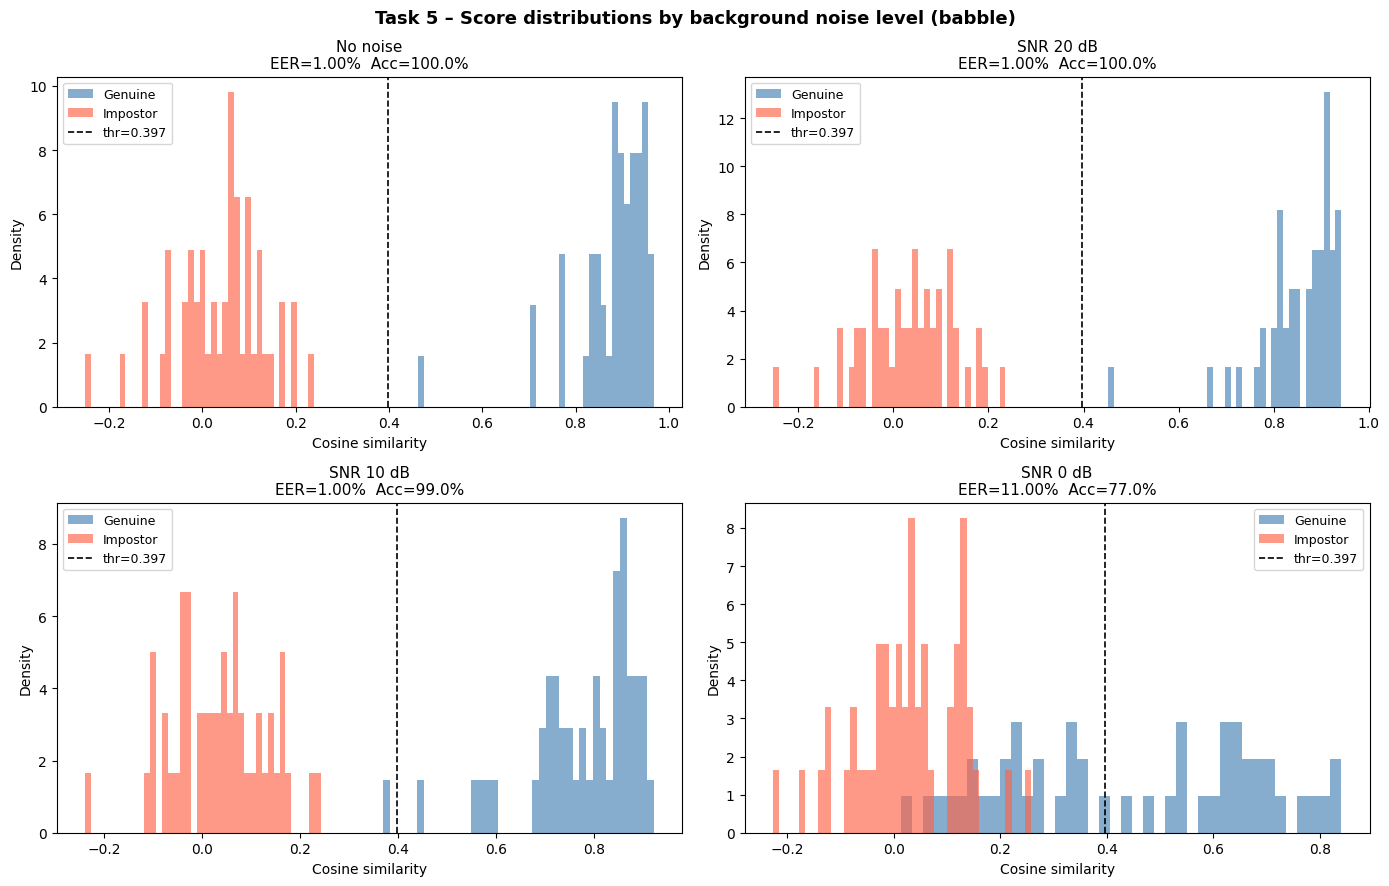

Saved: D:\pwr\biometria\lab\voice\results\task5_score_distributions.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (key, label, snr_db) in zip(axes.flat, CONDITIONS):
    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])

    ax.hist(gen, bins=40, alpha=0.65, color="steelblue", density=True, label="Genuine")
    ax.hist(imp, bins=40, alpha=0.65, color="tomato",    density=True, label="Impostor")
    ax.axvline(eer_threshold, color="black", linestyle="--", linewidth=1.2,
               label=f"thr={eer_threshold:.3f}")

    row_data = next((r for r in rows if r["key"] == key), None)
    if row_data:
        eer_f, _ = compute_eer(gen, imp)
        ax.set_title(
            f"{label}\nEER={eer_f*100:.2f}%  Acc={row_data['accuracy_pct']:.1f}%",
            fontsize=11,
        )
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

noise_type = "babble" if USE_BABBLE else "environmental (UrbanSound8K)"
fig.suptitle(
    f"Task 5 – Score distributions by background noise level ({noise_type})",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()

out = RESULTS_DIR / "task5_score_distributions.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 9. Degradation curves (EER & Accuracy vs. SNR)

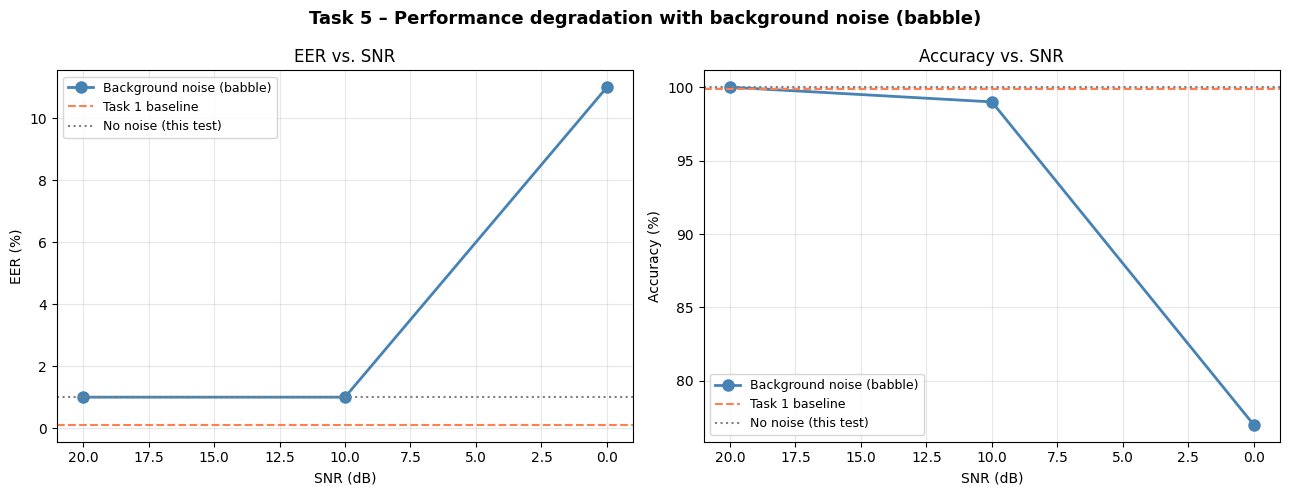

Saved: D:\pwr\biometria\lab\voice\results\task5_degradation.png


In [10]:
noisy_rows   = [r for r in rows if r["snr_db"] is not None]
snr_vals     = [r["snr_db"]       for r in noisy_rows]
eer_vals     = [r["eer_pct"]      for r in noisy_rows]
acc_vals     = [r["accuracy_pct"] for r in noisy_rows]
no_noise_row = next((r for r in rows if r["snr_db"] is None), None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, vals, ylabel, title, task1_val, no_noise_val in [
    (
        axes[0], eer_vals, "EER (%)", "EER vs. SNR",
        task1["eer_pct"],
        no_noise_row["eer_pct"] if no_noise_row else None,
    ),
    (
        axes[1], acc_vals, "Accuracy (%)", "Accuracy vs. SNR",
        task1["accuracy_at_eer_pct"],
        no_noise_row["accuracy_pct"] if no_noise_row else None,
    ),
]:
    ax.plot(
        snr_vals, vals, "o-",
        color="steelblue", linewidth=2, markersize=8,
        label=f"Background noise ({noise_type})",
    )
    ax.axhline(task1_val, color="coral",  linestyle="--", linewidth=1.5, label="Task 1 baseline")
    if no_noise_val is not None:
        ax.axhline(no_noise_val, color="gray", linestyle=":",  linewidth=1.5, label="No noise (this test)")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_xaxis()  # high SNR (clean) on left, low SNR (noisy) on right
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    f"Task 5 – Performance degradation with background noise ({noise_type})",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()

out = RESULTS_DIR / "task5_degradation.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 10. Comparison with Task 1

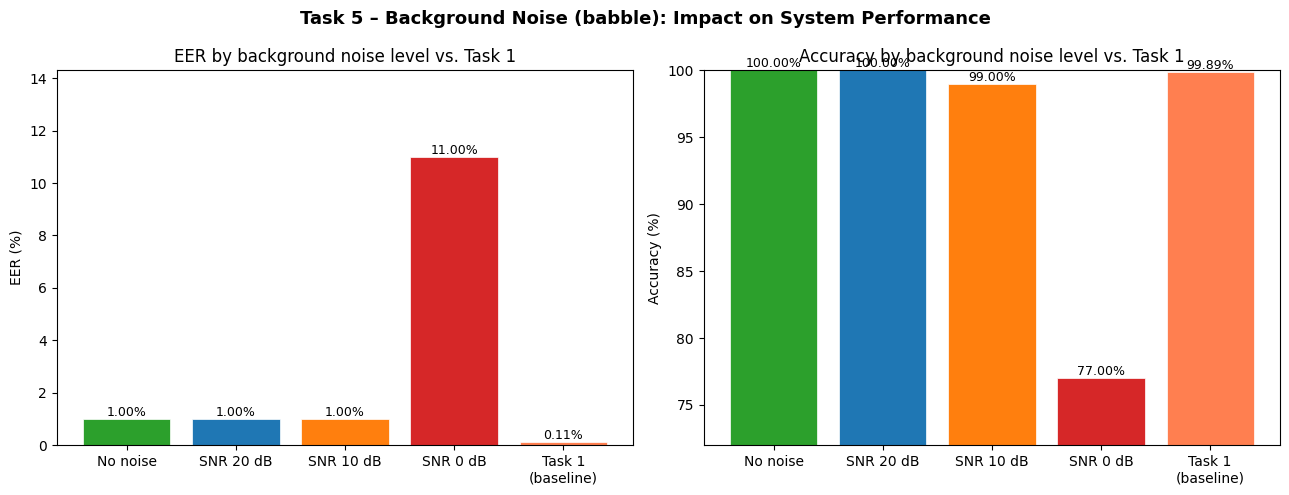

Saved: D:\pwr\biometria\lab\voice\results\task5_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels  = [r["label"] for r in rows] + ["Task 1\n(baseline)"]
eer_cmp = [r["eer_pct"]      for r in rows] + [task1["eer_pct"]]
acc_cmp = [r["accuracy_pct"] for r in rows] + [task1["accuracy_at_eer_pct"]]
colors  = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "coral"]

for ax, vals, ylabel, title in [
    (axes[0], eer_cmp,  "EER (%)",      "EER by background noise level vs. Task 1"),
    (axes[1], acc_cmp,  "Accuracy (%)", "Accuracy by background noise level vs. Task 1"),
]:
    bars = ax.bar(labels, vals, color=colors[:len(vals)], edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.2f%%", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].set_ylim(0, max(eer_cmp) * 1.3)
axes[1].set_ylim(max(0, min(acc_cmp) - 5), 100)

fig.suptitle(
    f"Task 5 – Background Noise ({noise_type}): Impact on System Performance",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()

out = RESULTS_DIR / "task5_comparison.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 11. Save results

In [12]:
summary = {
    "task": 5,
    "description": "Background noise at SNR 20/10/0 dB",
    "noise_source": noise_source_label,
    "n_trials": len(trials),
    "eer_threshold_used": eer_threshold,
    "per_condition": rows,
    "task1_eer_pct":      task1["eer_pct"],
    "task1_accuracy_pct": task1["accuracy_at_eer_pct"],
}

out_json = RESULTS_DIR / "task5_results.json"
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "═" * 56)
print("  TASK 5 – BACKGROUND NOISE RESULTS")
print(f"  Noise source: {noise_source_label}")
print("═" * 56)
print(f"  {'Condition':<12} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("  " + "-" * 44)
for r in rows:
    print(
        f"  {r['label']:<12} {r['eer_pct']:>8.2f}"
        f" {r['far_pct']:>8.2f} {r['frr_pct']:>8.2f} {r['accuracy_pct']:>8.2f}"
    )
print("  " + "-" * 44)
print(
    f"  {'Baseline (T1)':<12} {task1['eer_pct']:>8.2f}"
    f" {task1['far_at_eer_pct']:>8.2f} {task1['frr_at_eer_pct']:>8.2f} {task1['accuracy_at_eer_pct']:>8.2f}"
)
print("═" * 56)
print(f"\nJSON saved: {out_json}")


════════════════════════════════════════════════════════
  TASK 5 – BACKGROUND NOISE RESULTS
  Noise source: babble
════════════════════════════════════════════════════════
  Condition        EER%     FAR%     FRR%     Acc%
  --------------------------------------------
  No noise         1.00     0.00     0.00   100.00
  SNR 20 dB        1.00     0.00     0.00   100.00
  SNR 10 dB        1.00     0.00     2.00    99.00
  SNR 0 dB        11.00     0.00    46.00    77.00
  --------------------------------------------
  Baseline (T1)     0.11     0.14     0.07    99.89
════════════════════════════════════════════════════════

JSON saved: D:\pwr\biometria\lab\voice\results\task5_results.json
